In [1]:
# Force-install stable versions to avoid NumPy 2.x conflicts
!pip install "numpy<2" pandas scikit-learn pillow opencv-python joblib


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
    --------------------------------------- 0.5/39.5 MB 4.2 MB/s eta 0:00:10
   --- ------------------------------------ 3.1/39.5 MB 9.7 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/39.5 MB 9.2 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/39.5 MB 9.5 MB/s eta 0:00:04
   ---------- ----------------------------- 10.2/39.5 MB 10.6 MB/s eta 0:00:03
   -------------- ------------------------- 14.2/39.5 MB 12.2 MB/s eta 0:00:03
   ------------------- -------------------- 18.9/39.5 MB 13.7 MB/s eta 0:00:02
   -------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.0.0 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 6.32.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import warnings

warnings.filterwarnings('ignore')
print(f"✅ Step 2: Libraries loaded. NumPy version: {np.__version__}")


✅ Step 2: Libraries loaded. NumPy version: 1.26.4


In [3]:
DATASET_DIR = '../dataset/plant-pathology-2020'
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')

if not os.path.exists(os.path.join(DATASET_DIR, 'train.csv')):
    print("❌ Error: train.csv not found. Check your DATASET_DIR path.")
else:
    train_df = pd.read_csv(os.path.join(DATASET_DIR, 'train.csv'))
    CLASS_NAMES = ['healthy', 'multiple_diseases', 'rust', 'scab']
    train_df['label'] = train_df[CLASS_NAMES].idxmax(axis=1)
    
    print(f"✅ Samples found: {len(train_df)}")
    print("Class distribution:")
    print(train_df['label'].value_counts())


✅ Samples found: 1821
Class distribution:
label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64


In [4]:
IMG_SIZE = 64 # Resizing for speed

def get_features(img_id):
    path = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
    try:
        # Load, resize, and flatten image to a simple list of numbers
        img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        return np.array(img).flatten() / 255.0
    except Exception as e:
        return np.zeros(IMG_SIZE * IMG_SIZE * 3)

print("⏳ Extracting image features... (Please wait about 1 minute)")
X = np.array([get_features(id) for id in train_df['image_id']])
y = train_df['label']

print(f"✅ Features extracted. Shape: {X.shape}")


⏳ Extracting image features... (Please wait about 1 minute)
✅ Features extracted. Shape: (1821, 12288)


In [5]:
# Split into Training (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 Training Model (Random Forest)...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Check Accuracy
preds = model.predict(X_val)
acc = accuracy_score(y_val, preds)

print(f"\n✅ SUCCESS!")
print(f"Validation Accuracy: {acc:.2%}")

# Save the model to your backend/models folder
# (If the folder doesn't exist, it saves in the current folder)
model_path = 'plant_disease_model.pkl'
joblib.dump(model, model_path)
print(f"💾 Model saved as: {model_path}")


🚀 Training Model (Random Forest)...

✅ SUCCESS!
Validation Accuracy: 50.14%
💾 Model saved as: plant_disease_model.pkl


🚀 Starting Neural Network Training (Epochs)...
Iteration 1, loss = 8.87297953
Iteration 2, loss = 1.70105472
Iteration 3, loss = 1.27764347
Iteration 4, loss = 1.26708643
Iteration 5, loss = 1.27158911
Iteration 6, loss = 1.27189418
Iteration 7, loss = 1.27098909
Iteration 8, loss = 1.27149559
Iteration 9, loss = 1.27060939
Iteration 10, loss = 1.27172804
Iteration 11, loss = 1.27187991
Iteration 12, loss = 1.27150349
Iteration 13, loss = 1.27167821
Iteration 14, loss = 1.27019685
Iteration 15, loss = 1.27334503
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

✅ Training Complete!
Final Validation Accuracy: 32.88%


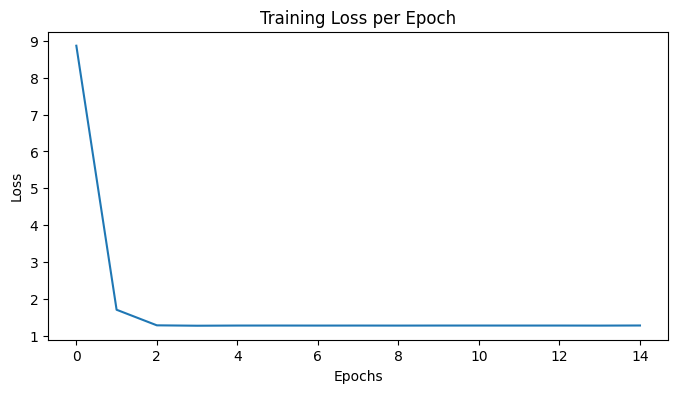

💾 Neural Network saved as: plant_disease_nn_model.pkl


In [6]:
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# 1. Initialize the Neural Network
# - hidden_layer_sizes=(100, 50) means two layers of neurons
# - max_iter=20 is the number of EPOCHS
# - verbose=True will print the progress of each epoch
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50), 
    max_iter=20, 
    alpha=1e-4,
    solver='sgd', 
    verbose=True, 
    random_state=42,
    learning_rate_init=.1
)

print("🚀 Starting Neural Network Training (Epochs)...")
# We use the X and y from Step 4 and 5
mlp.fit(X_train, y_train)

# 2. Evaluate performance
val_accuracy = mlp.score(X_val, y_val)
print(f"\n✅ Training Complete!")
print(f"Final Validation Accuracy: {val_accuracy:.2%}")

# 3. Plot the 'Loss Curve' (This shows the training progress over epochs)
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.title("Training Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# 4. Save the Neural Network
model_path = 'plant_disease_nn_model.pkl'
joblib.dump(mlp, model_path)
print(f"💾 Neural Network saved as: {model_path}")
